In [15]:
import pandas as pd
from os import listdir
from os.path import isfile, join
import numpy as np

In [16]:
def get_abs(abs_df, plate_template, absorbance, line):
    '''
    Function to extract the particular absorbance of a certain cell line and return that as a list
    
    Variables:
        abs_df = the pandas dataframe that contains the absorbances of all cell lines
        plate_template = the positioning of the lines on each of the cell plates
        absorbance = well...pretty self explainatory 
        line = cell line that you're intersted in 
    '''
    
    #first reformat the last column of the spreadsheet to only contain the absorbance as a number
    abs_df["Unnamed: 14"] = pd.to_numeric(abs_df["Unnamed: 14"].replace("Read [123]:", "", regex = True))
    #Filter by absorbance
    filtered_df = abs_df.loc[abs_df["Unnamed: 14"] == absorbance].reset_index(drop=True)
    #Filter by line
    values = filtered_df.where(plate_template == line).apply(lambda x: x.dropna().to_list())
    #Filter to only get lists with items 
    if isinstance(values, pd.DataFrame):
        return [0,0,0,0,0,0,0,0]
    
    else:
        abs_list = values[values.str.len() > 0].to_list()
        #Flatten the list (i.e. condense it to 1 list)
        abs_list = sum(abs_list, [])
        return np.array(abs_list)

In [17]:
cell_lines = [3059, 1691, 1690, 2342, 4532, 2344, 2343, 1952, 2931, "JG5", "BMS"] #2932
abs_lst = [680,750]
temperature = [25, 32, 28]

#Get the positions of the lines on their plates
plate_template = pd.read_excel("Plate_template.xlsx", sheet_name = 0)

In [18]:
absorbance_dict = {}
temp_data = [53,104,155]# Line numbers of where the temperature data starts
#go through the excel files in the cwd
for f in listdir("./"):
    if f == "Plate_template.xlsx":
        continue
    print(f)
    f_name = f.strip().split(".")
    #only look at files that end in an xl format
    if isfile(join("./", f)) and (f_name[-1][:2] == "xl"):
        for index in [0,1,2]: 
            #go through every plate layout in the file (0 = 25°C, 1 = 30°C, 2 = 35°C)
            abs_df = pd.read_excel(f, usecols = "B:O", skiprows = temp_data[index], nrows = 48)
            for line in cell_lines:
                for absorb in abs_lst:
                    key = "{abso}_{temp}_{cell_line}".format(abso = absorb, temp = temperature[index], cell_line = line)
                    abs_data = get_abs(abs_df, plate_template, absorb, line)
                    if len(abs_data) >= 8:
                        absorbance_dict[f_name[0]+"_"+key] = list(abs_data)
                        if len(abs_data) != 8:
                            print(key)

20230717-9PM.xls
20230721-9PM.xls
20230719-9AM.xls
Spec_Script_32_28.ipynb
20230720-9PM.xls
.DS_Store
20230718-9AM.xls
20230717-11AM.xls
20230719-3PM.xls
20230718-3PM.xls
20230721-9AM.xls
20230719-9PM.xls
20230720-9AM.xls
20230718-9PM.xls
.ipynb_checkpoints
20230721-3PM.xls
20230717-3PM.xls
20230720-3PM.xls


In [19]:
#len(absorbance_dict["20230703-9pm_680_25_2344"])

In [20]:
data_sorted = pd.DataFrame(absorbance_dict)

data_sorted.shape
data_sorted["Replicate"] = data_sorted.index
print(data_sorted.shape)
data_sorted

(8, 991)


,20230717-9PM_680_25_3059,20230717-9PM_750_25_3059,20230717-9PM_680_25_1691,20230717-9PM_750_25_1691,20230717-9PM_680_25_1690,20230717-9PM_750_25_1690,20230717-9PM_680_25_2342,20230717-9PM_750_25_2342,20230717-9PM_680_25_4532,20230717-9PM_750_25_4532,...,20230720-3PM_750_28_2343,20230720-3PM_680_28_1952,20230720-3PM_750_28_1952,20230720-3PM_680_28_2931,20230720-3PM_750_28_2931,20230720-3PM_680_28_JG5,20230720-3PM_750_28_JG5,20230720-3PM_680_28_BMS,20230720-3PM_750_28_BMS,Replicate
0,0.178,0.103,0.359,0.179,0.203,0.133,0.188,0.101,0.085,0.059,...,1.189,0.963,0.614,1.682,1.247,1.294,0.774,1.120,0.703,0
1,0.246,0.128,0.306,0.154,0.359,0.183,0.220,0.111,0.229,0.128,...,1.272,2.172,1.172,1.618,1.087,1.216,0.760,1.170,0.759,1
2,0.215,0.114,0.377,0.163,0.572,0.319,0.162,0.100,0.214,0.084,...,0.837,1.587,1.081,1.234,0.912,1.165,0.724,1.438,0.897,2
3,0.205,0.111,0.324,0.166,0.279,0.169,0.254,0.120,0.145,0.087,...,0.968,1.013,0.620,1.566,1.183,1.344,0.804,1.050,0.605,3
4,0.183,0.104,0.273,0.135,0.292,0.173,0.038,0.042,0.185,0.087,...,0.831,1.619,1.023,1.458,1.100,0.979,0.580,1.315,0.951,4
5,0.215,0.116,0.252,0.129,0.285,0.168,0.191,0.101,0.177,0.088,...,1.050,0.903,0.605,1.617,1.116,1.250,0.751,1.141,0.744,5
6,0.246,0.136,0.285,0.145,0.333,0.194,0.170,0.087,0.193,0.095,...,1.079,1.116,0.818,1.547,1.071,1.519,0.707,1.537,0.947,6
7,0.219,0.120,0.330,0.172,0.245,0.148,0.227,0.109,0.216,0.079,...,0.969,0.981,0.694,1.419,0.936,1.336,0.849,0.897,0.571,7


In [21]:
data_sorted = data_sorted.melt(id_vars = ["Replicate"])
print(data_sorted.shape)
data_sorted["ID"] = data_sorted["variable"].astype("str") + "_"+ data_sorted["Replicate"].astype("str")
data_sorted = data_sorted[["ID","value"]]

(7920, 3)


In [22]:
#Reformat the dataframe
from datetime import datetime

data_sorted[['Hours', 'Absorbance', 'Temperature', 'Cell_Line', 'Replicate']] = data_sorted.ID.str.split("_", expand = True)
data_sorted[['Absorbance', 'Temperature', 'Replicate']] = data_sorted[['Absorbance', 'Temperature', 'Replicate']].apply(pd.to_numeric, errors='coerce', axis=1)
# data_sorted[["Cell_Line"]] = data_sorted[["Cell_Line"]].astype(int)

#Reformat the time and date column
data_sorted[["Hours"]] = data_sorted[["Hours"]].replace("am", "AM", regex=True)
data_sorted[["Hours"]] = data_sorted[["Hours"]].replace("pm", "PM", regex=True)
data_sorted["Hours"]  = pd.to_datetime(data_sorted["Hours"], format='%Y%m%d-%I%p')
data_sorted["Hours"] = (data_sorted["Hours"] - min(data_sorted["Hours"]))/np.timedelta64(1, 'h')

#ln transfomring the data
data_sorted["log10_transformed"] = pd.to_numeric(np.log10(data_sorted["value"]))


data_sorted.shape

(7920, 8)

In [23]:
data_sorted.head()
pd.unique(data_sorted.Cell_Line)

array(['3059', '1691', '1690', '2342', '4532', '2344', '2343', '1952',
       '2931', 'JG5', 'BMS'], dtype=object)

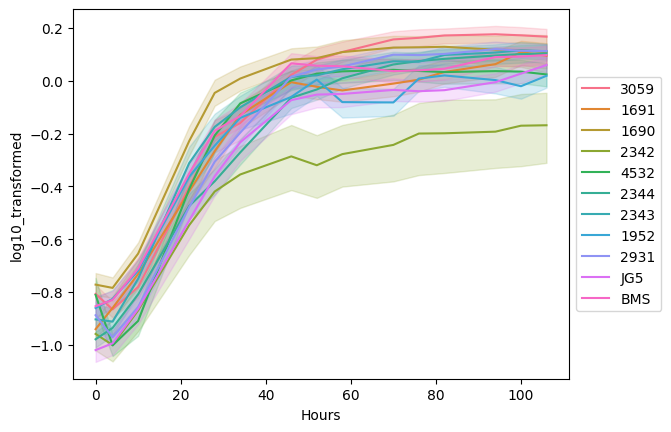

In [24]:
import seaborn as sns

plt = sns.lineplot(data = data_sorted, x = "Hours", y = "log10_transformed", hue = "Cell_Line")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

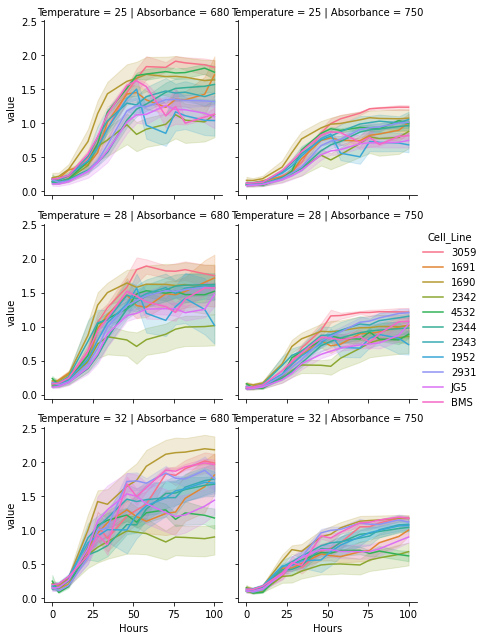

In [11]:
g = sns.FacetGrid(data_sorted, row="Temperature", col = "Absorbance", hue = "Cell_Line")
g.map(sns.lineplot,"Hours", "value")
g.add_legend()

In [14]:
data_sorted.to_csv("../../Cleaned_Data/25_32_28.csv")
data_sorted.head()

,ID,value,Hours,Absorbance,Temperature,Cell_Line,Replicate,log10_transformed
0,20230717-9PM_680_25_3059_0,0.178,10.0,680,25,3059,0,-0.749580
1,20230717-9PM_680_25_3059_1,0.246,10.0,680,25,3059,1,-0.609065
2,20230717-9PM_680_25_3059_2,0.215,10.0,680,25,3059,2,-0.667562
3,20230717-9PM_680_25_3059_3,0.205,10.0,680,25,3059,3,-0.688246
4,20230717-9PM_680_25_3059_4,0.183,10.0,680,25,3059,4,-0.737549


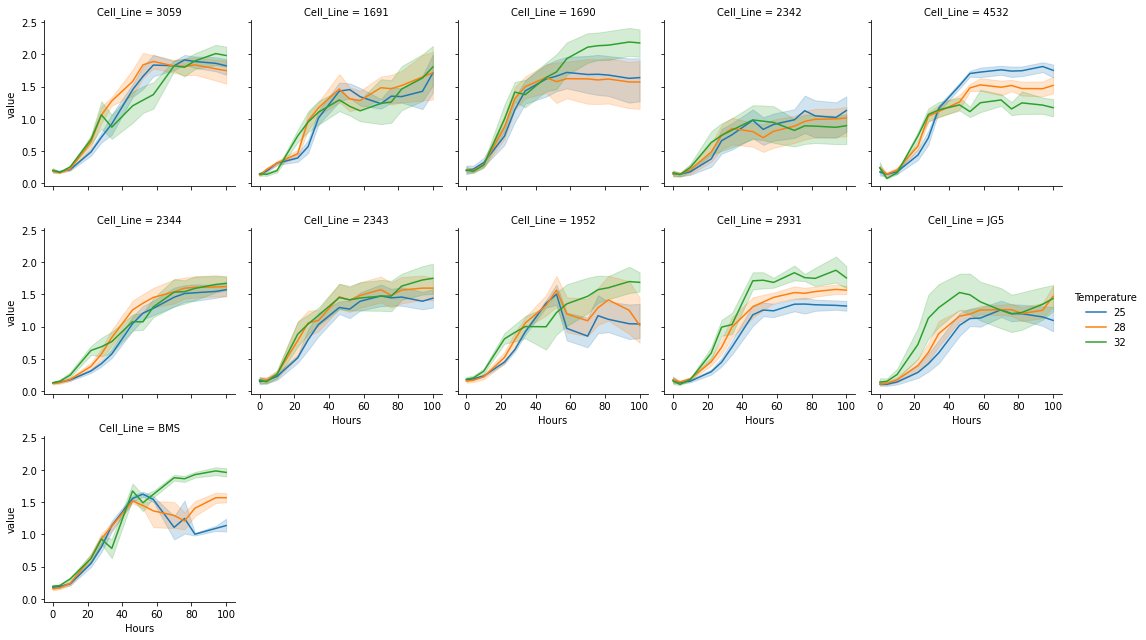

In [13]:
g = sns.FacetGrid(data_sorted[data_sorted["Absorbance"] == 680], col = "Cell_Line", col_wrap = 5, hue = "Temperature")
g.map(sns.lineplot,"Hours", "value")
g.add_legend()

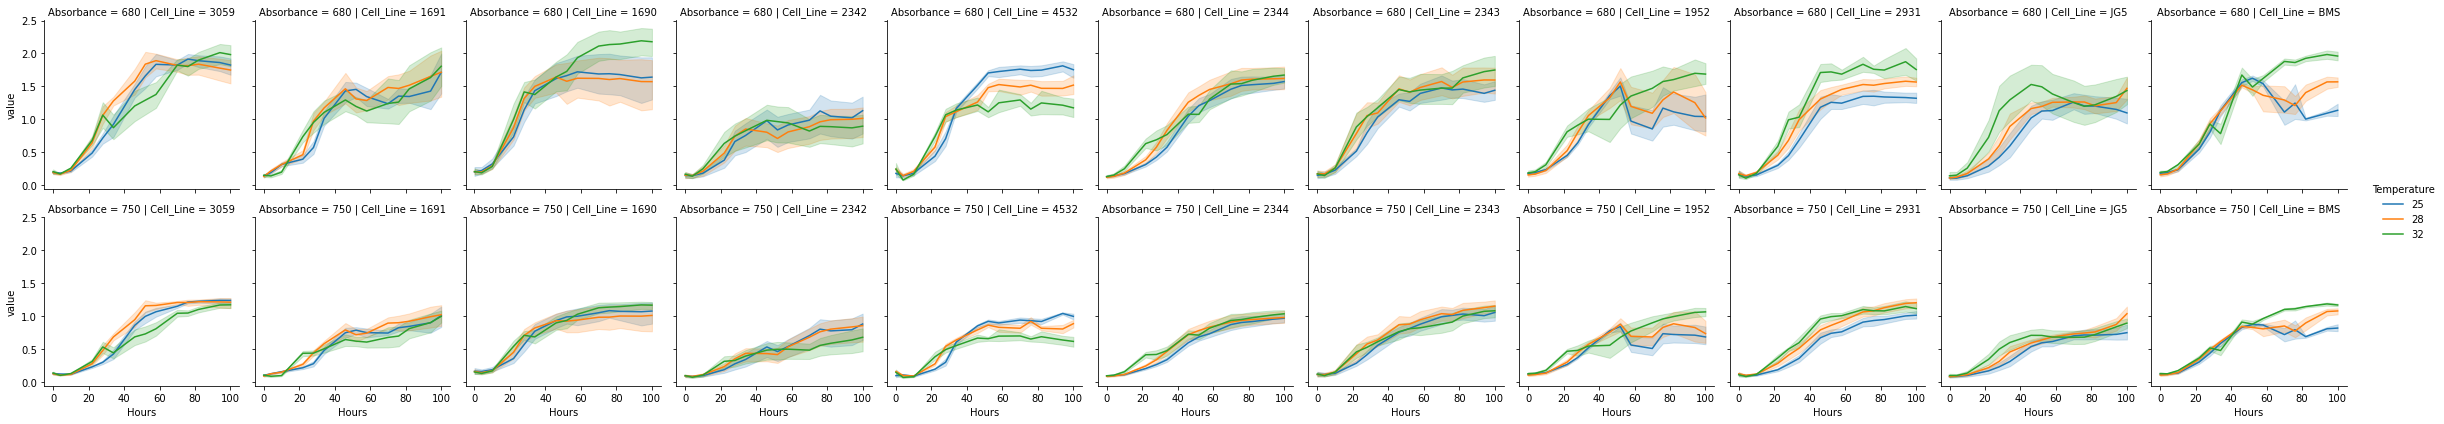

In [14]:
g = sns.FacetGrid(data_sorted, col="Cell_Line", row = "Absorbance", hue = "Temperature")
g.map(sns.lineplot,"Hours", "value")
g.add_legend()